# CMIP6 Cloud Properties: Cover, Liquid Water Path, and Ice Water Path


```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

## Introduction

Aerosols from sources such as dust, smoke, and fossil fuel combustion act as seeds around which cloud droplets and ice crystals form, directly shaping cloud cover, thickness, and lifetime. Understanding what these cloud properties look like under historical conditions is therefore the necessary first step before examining how aerosols disturb them. This notebook builds that foundation, setting the stage for the aerosol component of our cookbook.


## Overview
Clouds are one of the largest sources of uncertainty in climate models, and CMIP6 provides a rich, cloud-optimized archive for exploring how different models represent them. In this notebook, we access CMIP6 data hosted on Google Cloud through the Pangeo `intake-esm` catalog, then use it to map three cloud-related variables for the MPI-ESM1-2-HR model's historical run (1850–2014): total cloud cover, liquid water path, and ice water path. We close by comparing results across ensemble members, to get a sense of how much internal variability and model configuration can shift these fields.

By the end of this notebook, you'll be able to:
1. Search and load CMIP6 data directly from cloud storage using `intake-esm`
1. Merge multiple Zarr stores into a single `xarray` dataset with `dask`
1. Plot global maps of total cloud cover, liquid water path, and ice water path with `cartopy`
1. Compare cloud cover across model resolutions (coarse, high, and ultra high resolutions) and ensemble members


## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | Used for all map plotting in this notebook |
| [Intro to Xarray](https://foundations.projectpythia.org/core/xarray/xarray-intro) | Necessary | Core data structure for working with CMIP6 output |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| [Intro to Dask](https://foundations.projectpythia.org/core/dask/dask-overview) | Helpful | Used to parallelize dataset loading |

- **System requirements**: No additional system requirements beyond the packages listed in the Imports section below.


## Imports

In [3]:
from matplotlib import pyplot as plt
import sys
import numpy as np
import pandas as pd
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
from tqdm.autonotebook import tqdm  
import intake
import fsspec
from dask_gateway import Gateway
from dask.distributed import Client
from collections import defaultdict

%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6

/tmp/ipykernel_213/2766251797.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
col

/srv/conda/envs/notebook/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,60


In [5]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


## Total Cloud Cover

In [33]:
query = dict(
    experiment_id=['historical'],
    table_id='Amon',
    source_id="MPI-ESM1-2-HR",
    variable_id=["clt"],
    member_id='r2i1p1f1')
    # member_id='r1i1p1f1',)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
MPI-ESM1-2-HR,1,1,1


In [34]:
def drop_all_bounds(ds):
    """Drop coordinates like 'time_bounds' from datasets,
    which can lead to issues when merging."""
    drop_vars = [vname for vname in ds.coords
                 if (('_bounds') in vname ) or ('_bnds') in vname]
    return ds.drop_vars(drop_vars)

def open_dsets(df):
    """Open datasets from cloud storage and return xarray dataset."""
    dsets = [xr.open_zarr(fsspec.get_mapper(ds_url), consolidated=True)
             .pipe(drop_all_bounds)
             for ds_url in df.zstore]
    try:
        ds = xr.merge(dsets, join='exact')
        return ds
    except ValueError:
        return None

def open_delayed(df):
    """A dask.delayed wrapper around `open_dsets`.
    Allows us to open many datasets in parallel."""
    return dask.delayed(open_dsets)(df)

In [8]:
dsets = defaultdict(dict)
for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id']):
    dsets[group[0]][group[1]] = open_delayed(df)

In [9]:
opdepth_data = open_dsets(df)

In [10]:
opdepth_data

<xarray.Dataset> Size: 584MB
Dimensions:  (time: 1980, lat: 192, lon: 384)
Coordinates:
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time     (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T12...
Data variables:
    clt      (time, lat, lon) float32 584MB dask.array<chunksize=(258, 192, 384), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.5.0
    ...                     ...
    table_id:               Amon
    table_info:             Creation Date:(09 May 2019) MD5:e6ef8ececc8f33864...
    title:                  MPI-ESM1-2-HR output prepared for CMIP6
    tracking_id:            hdl:21.14100/1589af29-bc75-41cb-9507-643931f0b8ae...
    variable_id:            clt
    variant_label:          r1i1p1f1

In [11]:
opdepth_current = opdepth_data.isel(time = -1)

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


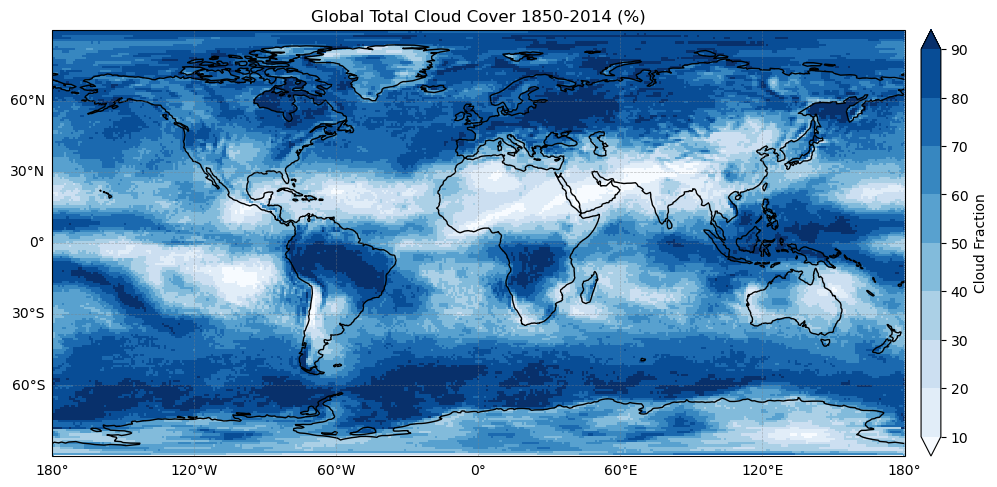

In [12]:
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
img = opdepth_current["clt"]
ax.set_global()
mesh = img.plot(ax=ax, transform=ccrs.PlateCarree(),
    cmap="Blues",
    levels=[10., 20., 30., 40., 50, 60, 70, 80, 90],
    add_colorbar=False)
grid = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
grid.top_labels = False
grid.right_labels = False
ax.coastlines(resolution='110m', color='black', linewidth=1)
plt.title("Global Total Cloud Cover 1850-2014 (%)")
fig.canvas.draw()
pos = ax.get_position()
cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.018, pos.height])
cbar = fig.colorbar(mesh, cax=cax, extend='both')
cbar.set_label("Cloud Fraction")
plt.savefig("cloud_fraction_2014.png", dpi=300, bbox_inches="tight")
plt.show()

This map shows where clouds cover the most of the sky on average, based on the model's historical run through 2014. The deep tropics and the mid-latitude storm tracks (roughly 40–60° in both hemispheres) stand out as the cloudiest regions, which matches what we'd expect physically. The tropics see frequent convective storms, while the mid-latitudes are dominated by large rotating weather systems that generate persistent cloud bands. Drier regions, like the subtropics around 20–30° latitude, show noticeably less cloud cover, consistent with the descending, dry air typical of those zones.

## Liquid Water Path

In [13]:
query = dict(
    experiment_id=['historical'], 
    table_id='Amon',                           
    source_id="MPI-ESM1-2-HR",
    variable_id=["clwvi"],
    member_id = 'r1i1p1f1',)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
MPI-ESM1-2-HR,1,1,1


In [14]:
def drop_all_bounds(ds):
    """Drop coordinates like 'time_bounds' from datasets,
    which can lead to issues when merging."""
    drop_vars = [vname for vname in ds.coords
                 if (('_bounds') in vname ) or ('_bnds') in vname]
    return ds.drop_vars(drop_vars)

def open_dsets(df):
    """Open datasets from cloud storage and return xarray dataset."""
    dsets = [xr.open_zarr(fsspec.get_mapper(ds_url), consolidated=True)
             .pipe(drop_all_bounds)
             for ds_url in df.zstore]
    try:
        ds = xr.merge(dsets, join='exact')
        return ds
    except ValueError:
        return None

def open_delayed(df):
    """A dask.delayed wrapper around `open_dsets`.
    Allows us to open many datasets in parallel."""
    return dask.delayed(open_dsets)(df)

In [15]:
dsets = defaultdict(dict)
for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id']):
    dsets[group[0]][group[1]] = open_delayed(df)

In [16]:
lwp_data = open_dsets(df)

In [17]:
lwp_data

<xarray.Dataset> Size: 584MB
Dimensions:  (time: 1980, lat: 192, lon: 384)
Coordinates:
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time     (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T12...
Data variables:
    clwvi    (time, lat, lon) float32 584MB dask.array<chunksize=(379, 192, 384), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.5.0
    ...                     ...
    table_id:               Amon
    table_info:             Creation Date:(09 May 2019) MD5:e6ef8ececc8f33864...
    title:                  MPI-ESM1-2-HR output prepared for CMIP6
    tracking_id:            hdl:21.14100/9f804d56-f81e-4851-b9eb-e50fdcd9344b...
    variable_id:            clwvi
    variant_label:          r1i1p1f1

In [18]:
lwp_current = lwp_data.isel(time = -1) * 1.e3

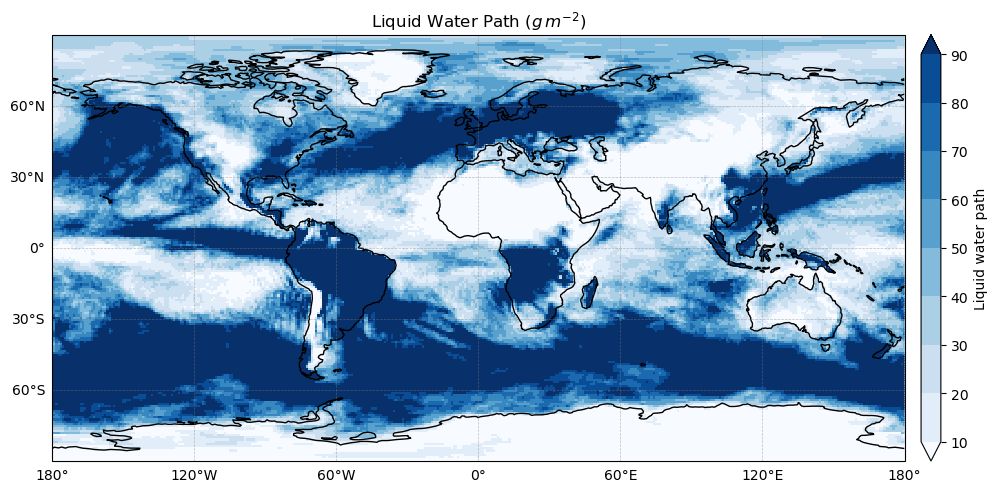

In [19]:
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
img = lwp_current["clwvi"]
ax.set_global()

mesh = img.plot(ax=ax,transform=ccrs.PlateCarree(),
    cmap="Blues",
    levels=[10., 20., 30., 40., 50, 60, 70, 80, 90],
    add_colorbar=False)          

grid = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
grid.top_labels = False
grid.right_labels = False
ax.coastlines(resolution='110m', color='black', linewidth=1)
plt.title(r"Liquid Water Path ($g\,m^{-2}$)")


fig.canvas.draw()                       
pos = ax.get_position()                 
cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.018, pos.height])
cbar = fig.colorbar(mesh, cax=cax, extend='both')
cbar.set_label("Liquid water path")

plt.savefig("Liquid_Water_Path_1850 - 2014.png", dpi=300, bbox_inches="tight")
plt.show()

Liquid water path tells us how much liquid water is packed into the clouds above each point on the globe, rather than just whether clouds are present. The highest values appear over the same mid-latitude storm tracks and parts of the tropics that showed high cloud cover above, suggesting those clouds aren't just frequent, they're also physically thick with liquid droplets. Lower values over the subtropics and polar regions point to thinner, less liquid-rich clouds in those areas.


## Ice Water Path

In [20]:
query = dict(
    experiment_id=['historical'], 
    table_id='Amon',                           
    source_id="MPI-ESM1-2-HR",
    variable_id=["clivi"],
    member_id = 'r1i1p1f1',)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()
dsets = defaultdict(dict)
for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id']):
    dsets[group[0]][group[1]] = open_delayed(df)

clivi_data = open_dsets(df)
clivi_current = clivi_data.isel(time = -1) 

In [21]:
clivi_current.clivi.units

'kg m-2'

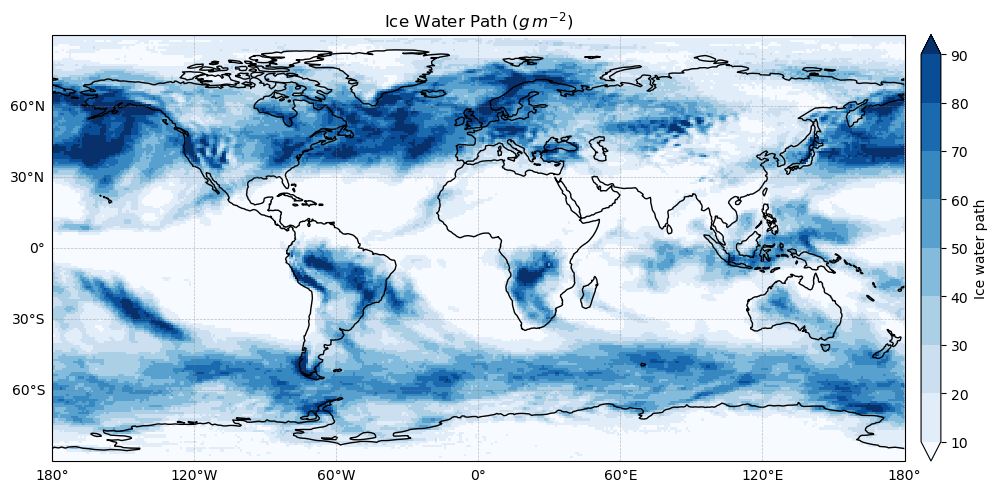

In [22]:
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
img = clivi_current["clivi"]*1.e3
ax.set_global()
mesh = img.plot(ax=ax, transform=ccrs.PlateCarree(),
    cmap="Blues",
    levels=[10., 20., 30., 40., 50, 60, 70, 80, 90],
    add_colorbar=False)
grid = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
grid.top_labels = False
grid.right_labels = False
ax.coastlines(resolution='110m', color='black', linewidth=1)
plt.title(r"Ice Water Path ($g\,m^{-2}$)")
fig.canvas.draw()
pos = ax.get_position()
cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.018, pos.height])
cbar = fig.colorbar(mesh, cax=cax, extend='both')
cbar.set_label("Ice water path")
plt.savefig("Ice_Water_Path_1850 - 2014.png", dpi=300, bbox_inches="tight")
plt.show()

Ice water path captures the ice content of clouds, which tends to dominate at colder, higher altitudes. Compared to the liquid water path map, the pattern here shifts further toward the tropics and high latitudes, where colder cloud tops support ice formation. This is a useful contrast: together, the liquid and ice water paths start to describe not just where clouds are, but what they're made of.

In [23]:
query = dict(
    experiment_id=['historical'], 
    table_id='Amon',                           
    source_id="MPI-ESM1-2-LR",
    variable_id=["clt"],
    member_id = 'r1i1p1f1',)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
MPI-ESM1-2-LR,1,1,1


Same model, different members

In [35]:
query = dict(
    experiment_id=['historical'],
    table_id='Amon',
    source_id="MPI-ESM1-2-HR",
    variable_id=["clt"],
    member_id='r2i1p1f1')
    # member_id='r1i1p1f1',)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
MPI-ESM1-2-HR,1,1,1


In [36]:
def drop_all_bounds(ds):
    """Drop coordinates like 'time_bounds' from datasets,
    which can lead to issues when merging."""
    drop_vars = [vname for vname in ds.coords
                 if (('_bounds') in vname ) or ('_bnds') in vname]
    return ds.drop_vars(drop_vars)

def open_dsets(df):
    """Open datasets from cloud storage and return xarray dataset."""
    dsets = [xr.open_zarr(fsspec.get_mapper(ds_url), consolidated=True)
             .pipe(drop_all_bounds)
             for ds_url in df.zstore]
    try:
        ds = xr.merge(dsets, join='exact')
        return ds
    except ValueError:
        return None

def open_delayed(df):
    """A dask.delayed wrapper around `open_dsets`.
    Allows us to open many datasets in parallel."""
    return dask.delayed(open_dsets)(df)

In [37]:
dsets = defaultdict(dict)
for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id']):
    dsets[group[0]][group[1]] = open_delayed(df)

In [38]:
# --- Load r2 member and build climatologies ---
clt_r2_data = open_dsets(col_subset.df)      # col_subset.df from the r2 query (cell 35)
clt_r2_clim = clt_r2_data["clt"].mean("time")

clt_r1_clim = opdepth_data["clt"].mean("time")   # opdepth_data holds the r1 clt loaded earlier

clt_diff = clt_r2_clim - clt_r1_clim             # internal-variability difference (r2 − r1)

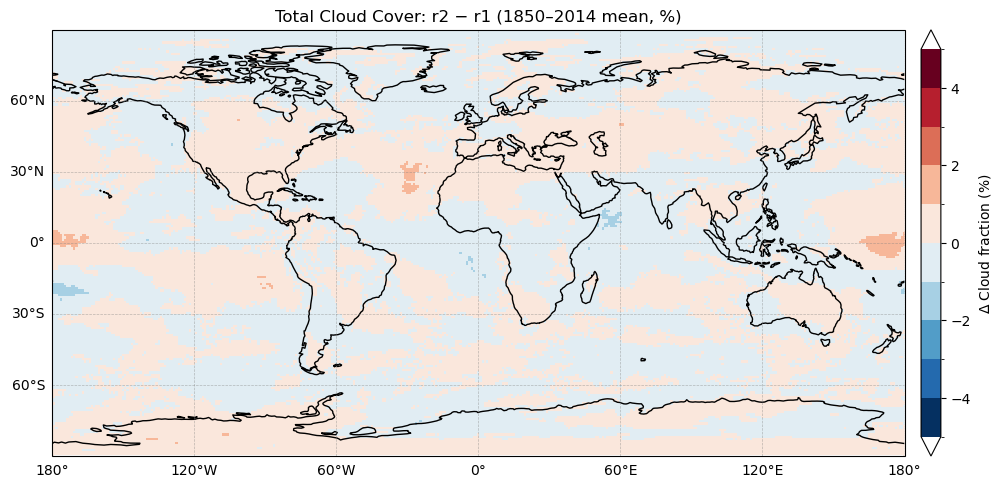

In [39]:
# --- Difference map ---
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_global()

mesh = clt_diff.plot(ax=ax, transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    levels=np.linspace(-5, 5, 11),   # tighter range matches the actual member spread
    add_colorbar=False)

grid = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
grid.top_labels = False
grid.right_labels = False
ax.coastlines(resolution='110m', color='black', linewidth=1)
plt.title("Total Cloud Cover: r2 − r1 (1850–2014 mean, %)")

fig.canvas.draw()
pos = ax.get_position()
cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.018, pos.height])
cbar = fig.colorbar(mesh, cax=cax, extend='both')
cbar.set_label(r"$\Delta$ Cloud fraction (%)")

plt.savefig("clt_member_diff_r2-r1.png", dpi=300, bbox_inches="tight")
plt.show()

## Ensemble Difference Map
This map shows the difference in 1850–2014 time-mean total cloud cover between ensemble members r2 and r1. Both runs use identical model physics and forcing, so any difference comes purely from natural variability. The small values across most of the globe confirm that averaging over 164 years is enough to largely cancel the noise, with the two members converging to a similar long-term climatology

## Summary

In this notebook, we used CMIP6 model output to map three cloud properties: total cloud cover, liquid water path, and ice water path from the MPI-ESM1-2-HR historical run (1850–2014), and compared cloud cover across two ensemble members to get a sense of natural model variability. These three variables are the same quantities that respond when aerosol concentrations change, making them the natural starting point for our cookbook. The aerosol component will build directly on this baseline to show what shifts when aerosol loading is increased or reduced.
